<a href="https://colab.research.google.com/github/hacker-194/FastAPI-insurance-project/blob/main/model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
db = sqlite3.connect("inventory.db")
tables = pd.read_sql_query("select name from sqlite_master where type='table'",db)


In [ ]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [ ]:
for table in tables["name"]:
  print("Table name", table)
  df = pd.read_sql_query("select * from " + table, db)
  print(df.head())

Table name purchases
           InventoryId  Store  Brand                   Description   Size  \
0    69_MOUNTMEND_8412     69   8412     Tequila Ocho Plata Fresno  750mL   
1     30_CULCHETH_5255     30   5255  TGI Fridays Ultimte Mudslide  1.75L   
2    34_PITMERDEN_5215     34   5215  TGI Fridays Long Island Iced  1.75L   
3  1_HARDERSFIELD_5255      1   5255  TGI Fridays Ultimte Mudslide  1.75L   
4    76_DONCASTER_2034     76   2034     Glendalough Double Barrel  750mL   

   VendorNumber                   VendorName  PONumber      PODate  \
0           105  ALTAMAR BRANDS LLC               8124  2023-12-21   
1          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
2          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
3          4466  AMERICAN VINTAGE BEVERAGE        8137  2023-12-22   
4           388  ATLANTIC IMPORTING COMPANY       8169  2023-12-24   

  ReceivingDate InvoiceDate     PayDate  PurchasePrice  Quantity  Dollars  \
0    2024-01-02  2

In [ ]:
vendor_df = pd.read_sql_query("select * from vendor_invoice",db)
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


looking for the corelation between quanity , freight and dollars


In [ ]:
vendor_df[["Quantity","Freight","Dollars"]].corr()

,Quantity,Freight,Dollars
Quantity,1.000000,0.946550,0.963831
Freight,0.946550,1.000000,0.985141
Dollars,0.963831,0.985141,1.000000


<Axes: >

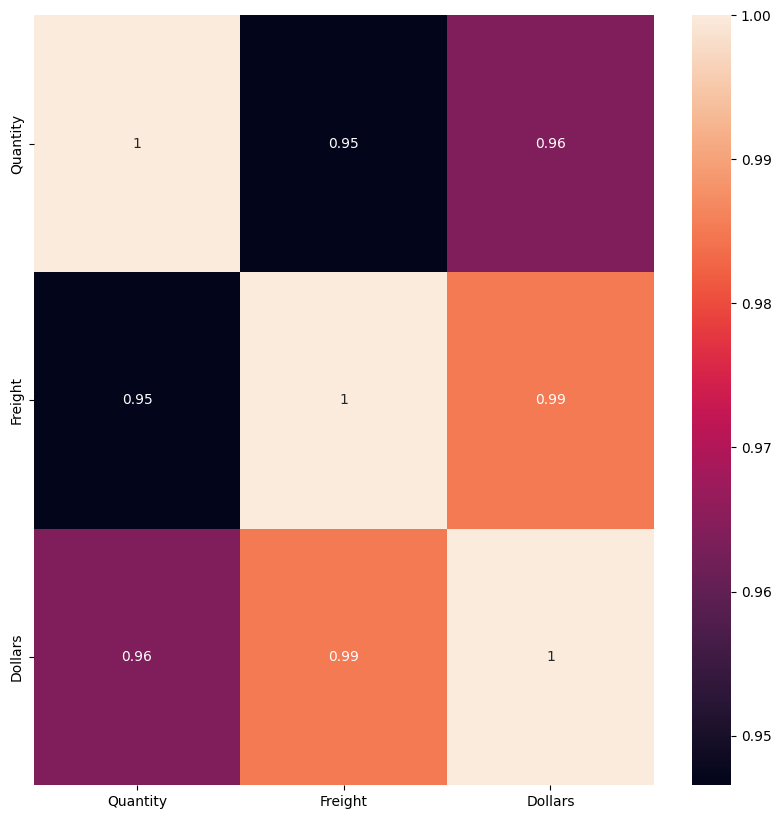

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(vendor_df[["Quantity","Freight","Dollars"]].corr(),annot=True)

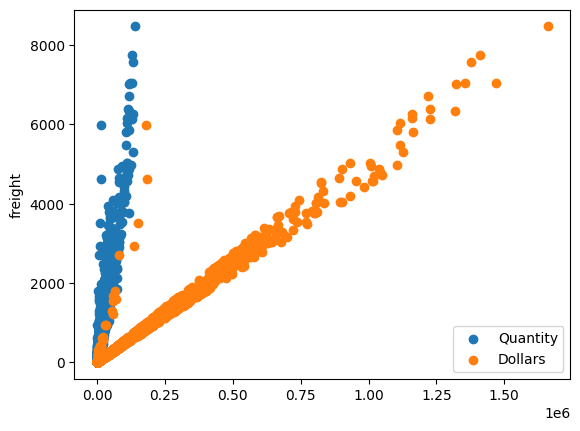

In [ ]:
plt.scatter(vendor_df["Quantity"],vendor_df["Freight"])
plt.scatter(vendor_df["Dollars"],vendor_df["Freight"])
plt.legend(["Quantity","Dollars"])
plt.ylabel("freight")
plt.show()

In [ ]:
vendor_df["freight_per_unit"]= vendor_df["Freight"]/vendor_df["Quantity"]

In [ ]:
vendor_df

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,freight_per_unit
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None,0.578333
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None,0.571333
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None,0.922000
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None,0.290614
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None,0.221809
...,...,...,...,...,...,...,...,...,...,...,...
5538,9622,WEIN BAUER INC,2025-01-06,13626,2024-12-21,2025-02-10,90,1563.00,8.60,None,0.095556
5539,9625,WESTERN SPIRITS BEVERAGE CO,2025-01-10,13661,2024-12-23,2025-02-18,4617,37300.48,186.50,None,0.040394
5540,3664,WILLIAM GRANT & SONS INC,2025-01-02,13643,2024-12-22,2025-02-04,9848,202815.78,932.95,None,0.094735
5541,9815,WINE GROUP INC,2025-01-03,13602,2024-12-20,2025-02-08,24747,149007.56,819.54,None,0.033117


In [ ]:
low_quanity = vendor_df["Quantity"].quantile(0.25)
high_quanity = vendor_df["Quantity"].quantile(0.75)

In [ ]:
high_quanity

np.float64(5100.5)

In [ ]:
low_quanity

np.float64(83.0)

In [ ]:
vendor_df.loc[vendor_df["Quantity"]<low_quanity,"freight_per_unit"].mean()

np.float64(0.09489854253138316)

In [ ]:
vendor_df.loc[vendor_df["Quantity"]>high_quanity,"freight_per_unit"].mean()

np.float64(0.049077654690759046)

In [ ]:
x = vendor_df[["Quantity","Dollars"]]
y = vendor_df["Freight"]

In [ ]:
vendor_df.describe().round()

,VendorNumber,PONumber,Quantity,Dollars,Freight,freight_per_unit
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,20663.0,10889.0,6059.0,58073.0,296.0,0.0
std,34582.0,1601.0,14453.0,140234.0,714.0,0.0
min,2.0,8106.0,1.0,4.0,0.0,0.0
25%,3089.0,9504.0,83.0,968.0,5.0,0.0
50%,7240.0,10890.0,423.0,4765.0,25.0,0.0
75%,10754.0,12276.0,5100.0,44587.0,230.0,0.0
max,201359.0,13661.0,141660.0,1660436.0,8468.0,3.0


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [ ]:
model1 = LinearRegression()
model1.fit(x_train,y_train)

model2 = DecisionTreeRegressor()
model2.fit(x_train,y_train)

model3 = RandomForestRegressor()
model3.fit(x_train,y_train)

RandomForestRegressor()

In [ ]:
import numpy as np

In [ ]:
# Predictions
y_pred1 = model1.predict(x_test)
y_pred2 = model2.predict(x_test)
y_pred3 = model3.predict(x_test)

# Function to calculate metrics
def get_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return r2, mae, rmse

# Metrics for each model
metrics1 = get_metrics(y_test, y_pred1)
metrics2 = get_metrics(y_test, y_pred2)
metrics3 = get_metrics(y_test, y_pred3)

# Print results
print("Linear Regression -> R2:", metrics1[0], "MAE:", metrics1[1], "RMSE:", metrics1[2])
print("Decision Tree     -> R2:", metrics2[0], "MAE:", metrics2[1], "RMSE:", metrics2[2])
print("Random Forest     -> R2:", metrics3[0], "MAE:", metrics3[1], "RMSE:", metrics3[2])

Linear Regression -> R2: 0.9700197330175596 MAE: 24.459180765263294 RMSE: 124.42878471171812
Decision Tree     -> R2: 0.9376382266159744 MAE: 33.72261524396354 RMSE: 179.4578001656844
Random Forest     -> R2: 0.9611879855677383 MAE: 28.167604494215922 RMSE: 141.57488042728767
